In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#reading .csv files using numpy
#genfromtxt handles mixed datatypes
male=np.genfromtxt('nhanes_adult_male_bmx_2020.csv',delimiter=',')
male

array([[  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [ 98.8, 182.3,  42. , ...,  38.2, 108.2, 120.4],
       [ 74.3, 184.2,  41.1, ...,  30.2,  94.5,  86.8],
       ...,
       [108.8, 168.7,  38.6, ...,  33.6, 118. , 114.7],
       [ 79.5, 176.4,  39.5, ...,  31.4,  99.8,  97.1],
       [ 59.7, 167.5,  40.3, ...,  29.2,  90.5,  86.9]], shape=(4082, 7))

In [4]:
female=np.genfromtxt('nhanes_adult_female_bmx_2020.csv',delimiter=',')
female

array([[  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [ 97.1, 160.2,  34.7, ...,  35.8, 126.1, 117.9],
       [ 91.1, 152.7,  33.5, ...,  38.5, 125.5, 103.1],
       ...,
       [ 73. , 159.6,  36.2, ...,  31.4, 104.6,  99.3],
       [ 78.6, 168.5,  38.1, ...,  36. , 102.4,  98.5],
       [ 82.8, 147.8,  34.8, ...,  39.5, 121.4, 110. ]], shape=(4222, 7))

In [5]:
#extract weights columns
male_weights=male[:,0]
female_weights=female[:,0]

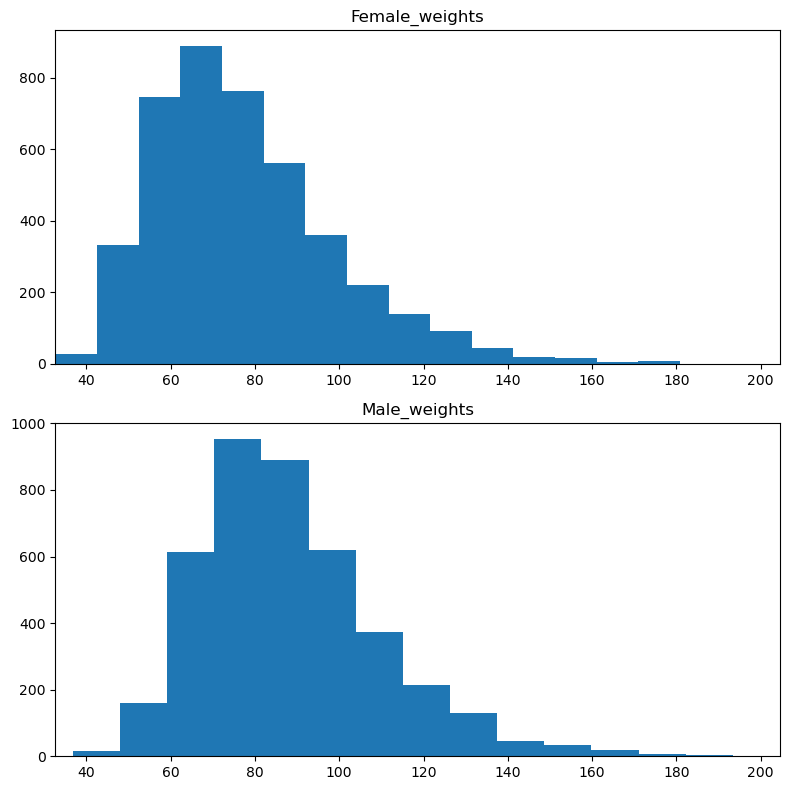

In [6]:
#3.plotting two histograms with same x-axis limits for both male and female
male_weights=male_weights[~np.isnan(male_weights)]
female_weights=female_weights[~np.isnan(female_weights)]
plt.figure(figsize=(8,8))
#finding common x-axis limits
min_w=min(np.min(male_weights),np.min(female_weights))
max_w=max(np.max(male_weights),np.max(female_weights))
#female weights
plt.subplot(2,1,1)
plt.hist(female_weights,bins=15)
plt.title("Female_weights")
plt.xlim(min_w, max_w)
#male weights
plt.subplot(2,1,2)
plt.hist(male_weights,bins=15)
plt.title("Male_weights")
plt.xlim(min_w, max_w)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7780/2048073981.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weights,male_weights],labels=["Female","Male"])


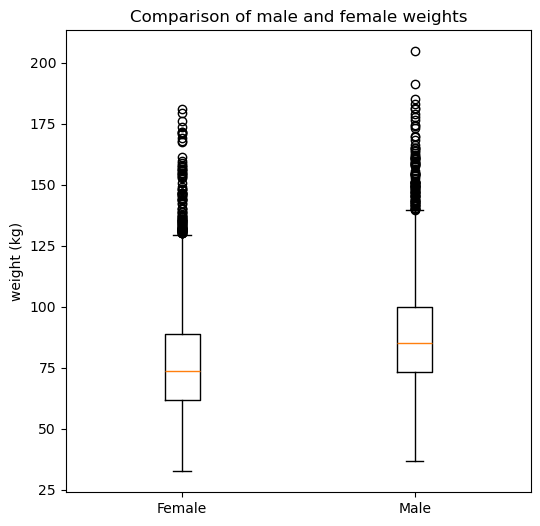

In [7]:
#4.boxplot comparision
plt.figure(figsize=(6,6))
plt.boxplot([female_weights,male_weights],labels=["Female","Male"])
plt.title("Comparison of male and female weights")
plt.ylabel("weight (kg)")
plt.show()

In [8]:
#5.numerical aggregates

from scipy.stats import skew, kurtosis

def describe(data):
    return {
        "Mean": np.mean(data),
        "Median": np.median(data),
        "Std Dev": np.std(data),
        "Variance": np.var(data),
        "Min": np.min(data),
        "Max": np.max(data),
        "Skewness": skew(data),
        "Kurtosis": kurtosis(data)
    }

male_stats = describe(male_weights)
female_stats = describe(female_weights)

print("Male Statistics:\n", male_stats)
print("\nFemale Statistics:\n", female_stats)

Male Statistics:
 {'Mean': np.float64(88.36454300416565), 'Median': np.float64(85.0), 'Std Dev': np.float64(21.418936717962495), 'Variance': np.float64(458.770850128082), 'Min': np.float64(36.8), 'Max': np.float64(204.6), 'Skewness': np.float64(0.9842810741662347), 'Kurtosis': np.float64(1.4742884754078238)}

Female Statistics:
 {'Mean': np.float64(77.40379057095475), 'Median': np.float64(73.6), 'Std Dev': np.float64(21.54250829019315), 'Variance': np.float64(464.07966343304065), 'Min': np.float64(32.6), 'Max': np.float64(180.9), 'Skewness': np.float64(1.03336107186799), 'Kurtosis': np.float64(1.4009683480659731)}


In [9]:
#6.adding BMI column to female matrix

# Extract weight and height
female_weights = female[:, 0]
female_height_cm = female[:, 1]

# Remove rows where height or weight is NaN
valid = (~np.isnan(female_weights)) & (~np.isnan(female_height_cm)) & (female_height_cm != 0)

female_clean = female[valid]

# Convert height to meters
height_m = female_clean[:, 1] / 100

# Compute BMI
bmi = female_clean[:, 0] / (height_m ** 2)

# Add BMI as 8th column
female_with_bmi = np.column_stack((female_clean, bmi))

print("New shape:", female_with_bmi.shape)


New shape: (4221, 8)


In [10]:
#7.creating zfemale -standardized female matrix

# Compute column means and std deviations
means = np.mean(female_with_bmi, axis=0)
stds = np.std(female_with_bmi, axis=0)

# Standardise all columns
zfemale = (female_with_bmi - means) / stds

print("Shape of zfemale:", zfemale.shape)

Shape of zfemale: (4221, 8)


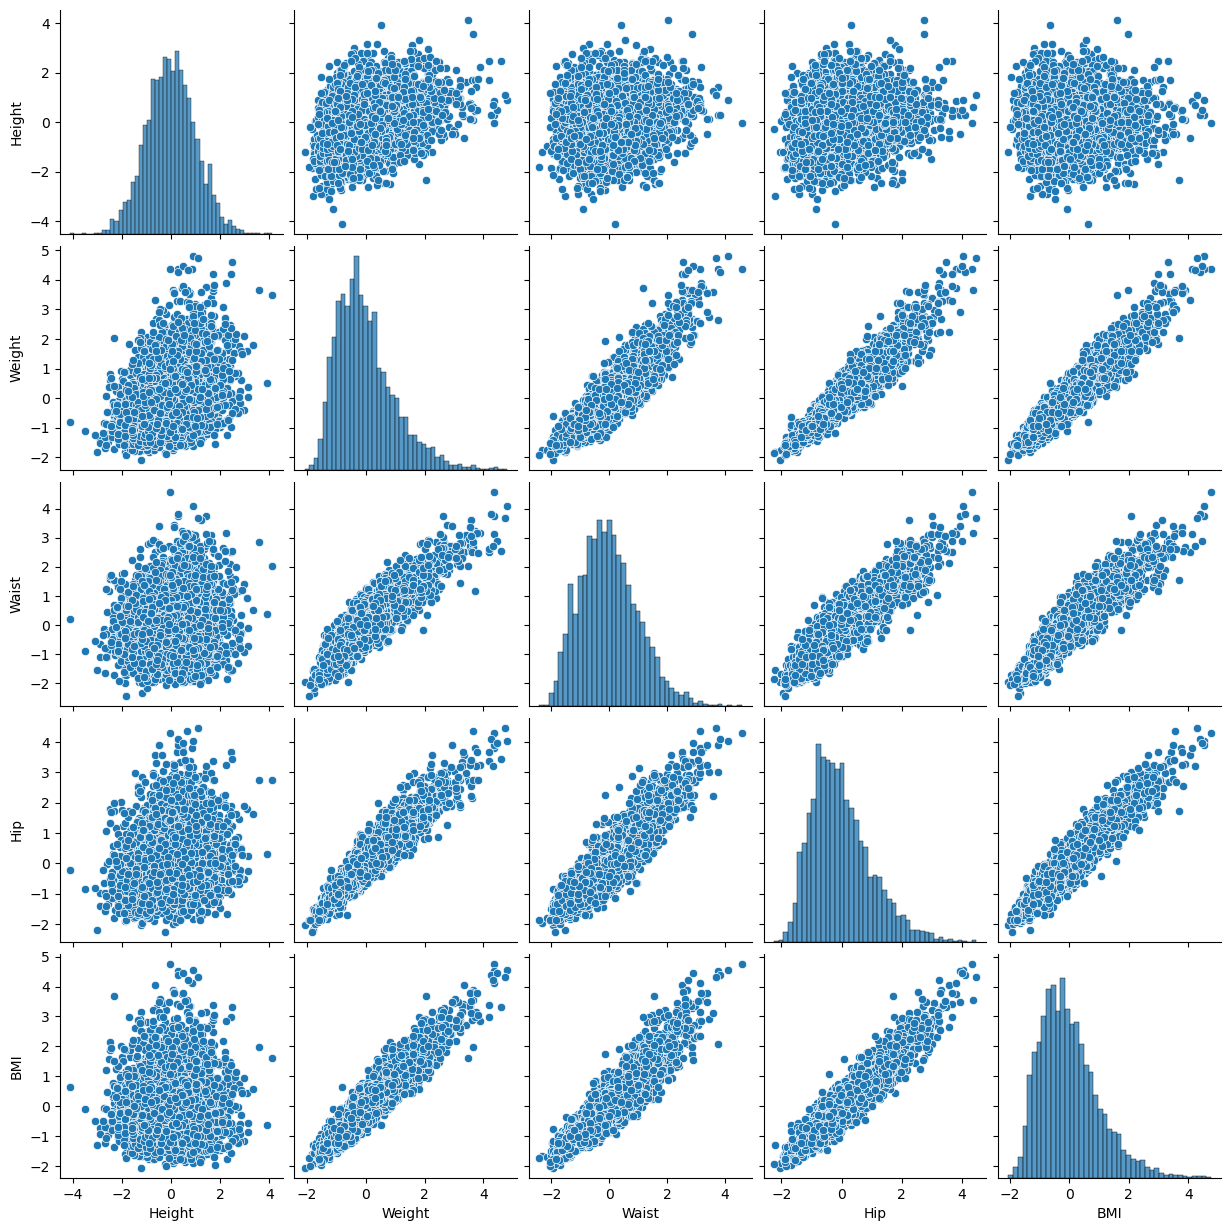

In [12]:
#8.pairplot +correlations

#scatterplot matrix(pair plot)
selected = zfemale[:, [1, 0, 6, 5, 7]]  # height, weight, waist, hip, BMI
df = pd.DataFrame(selected, columns=["Height", "Weight", "Waist", "Hip", "BMI"])

sns.pairplot(df)
plt.show()


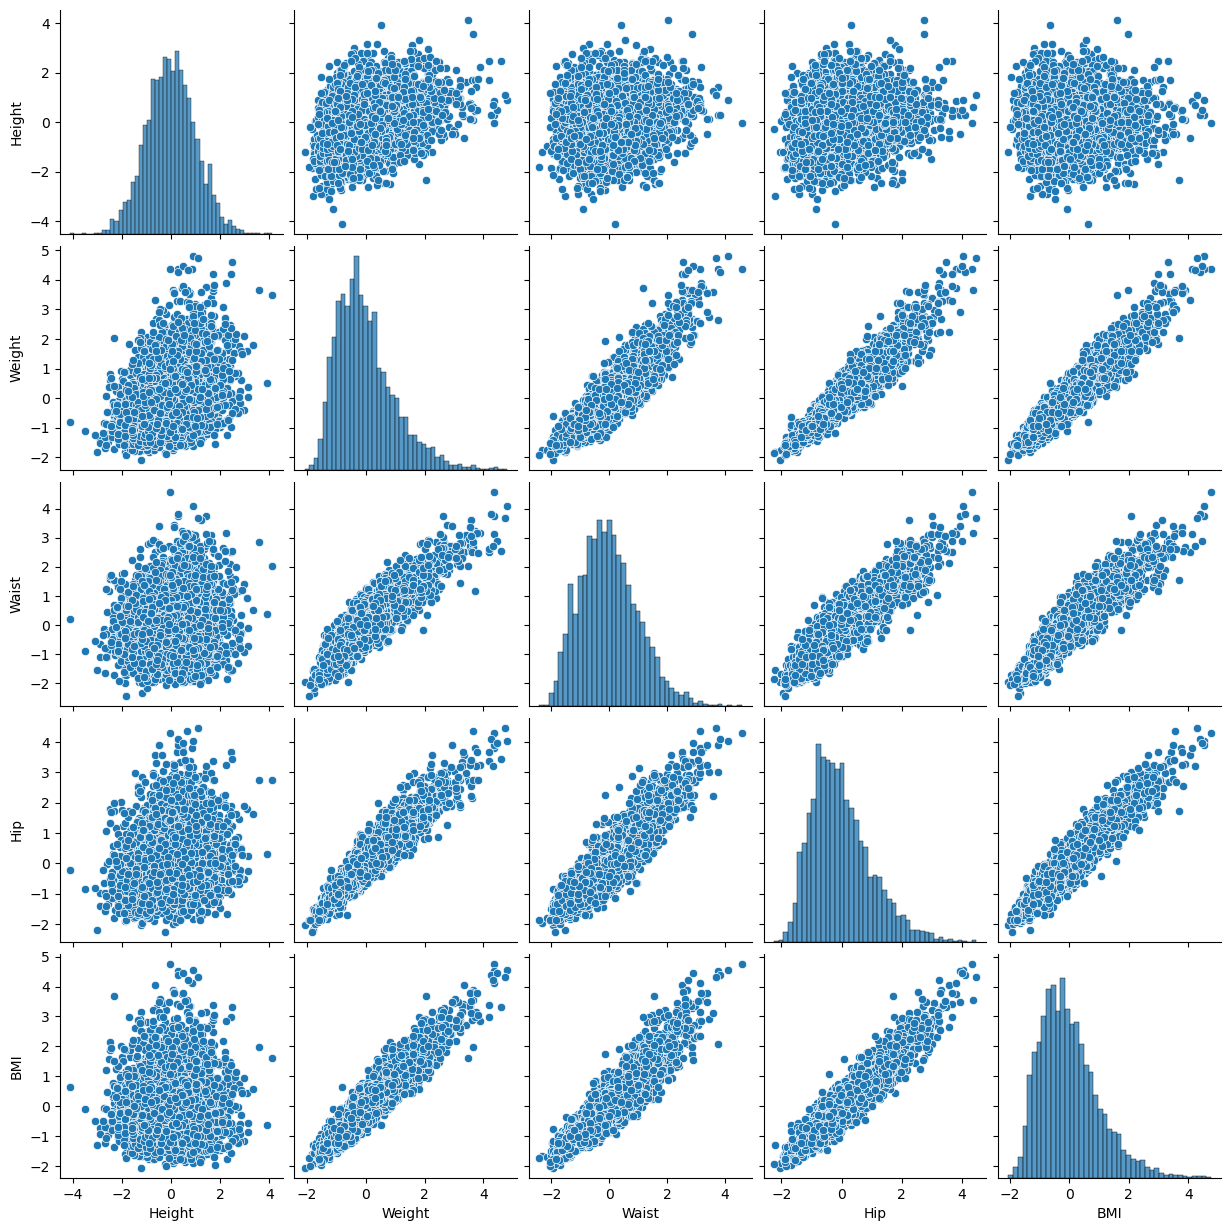

In [60]:
#9.


df = pd.DataFrame(selected, columns=["Height", "Weight", "Waist", "Hip", "BMI"])

sns.pairplot(df)
plt.show()

In [13]:
#adding waist ratios

#female
waist = female_with_bmi[:, 6]
height = female_with_bmi[:, 1]
hip = female_with_bmi[:, 5]
whtr_f = waist / height
whr_f = waist / hip
female_extended = np.column_stack((female_with_bmi, whtr_f, whr_f))
print("Female shape:", female_extended.shape)
print(female_extended[:5])

Female shape: (4221, 10)
[[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078   0.73595506   0.93497224]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037   0.67518009   0.82151394]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.          28.09265496   0.5707196    0.86629002]
 [ 61.7        157.4         38.          34.7         29.
  101.          90.5         24.90437849   0.57496823   0.8960396 ]
 [ 55.4        154.6         34.6         34.          28.3
   92.5         73.2         23.17879132   0.47347995   0.79135135]]


In [14]:
#male
waist_m = male[:, 6]
height_m = male[:, 1]
hip_m = male[:, 5]
whtr_m = waist_m / height_m
whr_m = waist_m / hip_m
male_extended = np.column_stack((male, whtr_m, whr_m))
print("Male shape:", male_extended.shape)
print(male_extended[:5])

Male shape: (4082, 9)
[[         nan          nan          nan          nan          nan
           nan          nan          nan          nan]
 [ 98.8        182.3         42.          40.1         38.2
  108.2        120.4          0.66044981   1.11275416]
 [ 74.3        184.2         41.1         41.          30.2
   94.5         86.8          0.47122693   0.91851852]
 [103.7        185.3         47.          44.          32.
  107.8        109.6          0.59147329   1.01669759]
 [ 86.         167.8         39.5         38.4         29.
  106.4        108.3          0.6454112    1.01785714]]


In [68]:
# Extract male columns
male_weights = male[:, 0]
male_height = male[:, 1]
male_hip = male[:, 5]
male_waist = male[:, 6]

# Remove rows with NaN or zero height
valid_m = (~np.isnan(male_height)) & (~np.isnan(male_waist)) & (~np.isnan(male_hip)) & (male_height != 0)

male_clean = male[valid_m]

# Recompute using clean data
male_height = male_clean[:, 1]
male_hip = male_clean[:, 5]
male_waist = male_clean[:, 6]

whtr_m = male_waist / male_height
whr_m = male_waist / male_hip

print("Male WHtR sample:", whtr_m[:5])
print("Male WHR sample:", whr_m[:5])

Male WHtR sample: [0.66044981 0.47122693 0.59147329 0.6454112  0.58920705]
Male WHR sample: [1.11275416 0.91851852 1.01669759 1.01785714 0.89018303]


/tmp/ipykernel_7780/3470229491.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


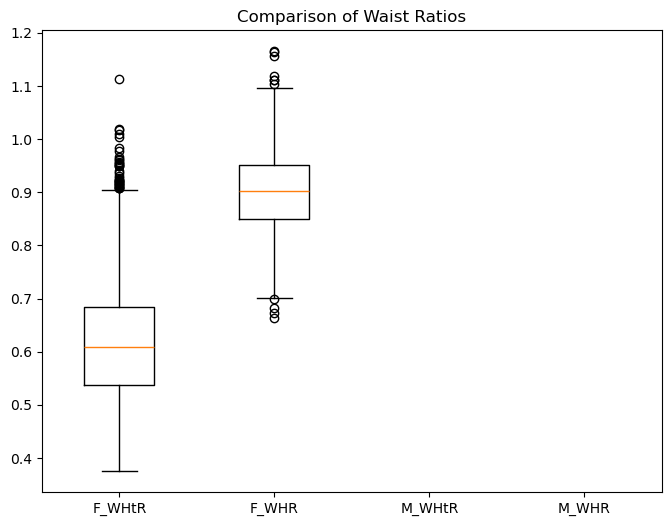

In [15]:
#box plot of 4 ratios

plt.figure(figsize=(8,6))
plt.boxplot([
    whtr_f, whr_f, whtr_m, whr_m
], labels=["F_WHtR", "F_WHR", "M_WHtR", "M_WHR"])
plt.title("Comparison of Waist Ratios")
plt.show()

In [ ]:
#11.Body Mass Index (BMI)


#Advantages
*Very easy to calculate (only height & weight needed)
*Cheap and non-invasive
*Useful for large population studies
*Standardized categories (underweight, normal, overweight, obese)
*Strongly associated with diabetes and heart disease risk
*Allows comparison across countries and time


#Disadvantages
*Does not distinguish fat from muscle
*Athletes may be classified as overweight
*Does not show fat distribution
*Ignores body frame size
*Less accurate for elderly (muscle loss not considered)
*Less accurate for different ethnic groups
*Cannot detect abdominal obesity specifically

# Waist-to-Height Ratio (WHtR)

    
#Advantages
*Good indicator of central (abdominal) obesity
*Strong predictor of cardiovascular disease
*Simple rule: Waist should be less than half your height
*Better risk indicator than BMI in many studies
*Works across different age groups
*More sensitive to fat distribution changes

    
#Disadvantages
*Requires accurate waist measurement
*Can vary depending on where waist is measured
*Does not account for hip size
*Not widely used in clinical settings compared to BMI
*Can misclassify very muscular individuals

#Waist-to-Hip Ratio (WHR)

    
#Advantages
*Measures fat distribution pattern
*Identifies “apple shape” vs “pear shape”
*Good predictor of metabolic syndrome
*More informative about abdominal fat than BMI
*Useful for gender-based comparisons

    
#Disadvantages
*Requires two measurements (waist & hip)
*Measurement errors are common
*Less intuitive than BMI
*Does not consider total body fat
*May not reflect changes if both waist & hip increase proportionally
*Not ideal for extremely obese individuals

In [70]:
#5 lowest & 5 highest BMI(standardised data)

# Get sorted indices based on BMI
sorted_indices = np.argsort(female_with_bmi[:, 7])

lowest5 = sorted_indices[:5]
highest5 = sorted_indices[-5:]

print("Lowest 5 BMI (standardised values):")
print(zfemale[lowest5])

print("\nHighest 5 BMI (standardised values):")
print(zfemale[highest5])


Lowest 5 BMI (standardised values):
[[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]

Highest 5 BMI (standardised values):
[[ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03